In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt



(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [ ]:
x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0
x_train=x_train.reshape(-1,784)
x_test=x_test.reshape(-1,784)

In [ ]:
def build_mlp_no_bn():

  model = models.Sequential([
      layers.Input(shape=(784,)),
      layers.Dense(256,activation='relu'),
      layers.Dense(128,activation='relu'),
      layers.Dense(10, activation='softmax')
  ])

  model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
  return model

In [ ]:
def build_mlp_with_bn():
  model=models.Sequential([
      layers.Input(shape=(784,)),
      layers.Dense(256),
      layers.BatchNormalization(),
      layers.Activation('relu'),
      layers.Dense(128),
      layers.BatchNormalization(),
      layers.Activation('relu'),
      layers.Dense(10,activation='softmax')
  ])
  model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
  return model


In [ ]:
def build_mlp_with_bn():
  model=models.Sequential([
      layers.Input(shape=(784,)),
      layers.Dense(256),
      layers.BatchNormalization(),
      layers.Activation('relu'),
      layers.Dense(128),
      layers.BatchNormalization(),
      layers.Activation('relu'),
      layers.Dense(10,activation='sigmoid')
  ])
  model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
  return model


In [ ]:
print("\nTraining MLP without Batch Normalization:")
model_no_bn = build_mlp_no_bn()
history_no_bn = model_no_bn.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2,verbose=1)
print("\nTraining MLP with Batch Normalization:")
model_bn = build_mlp_with_bn()
history_bn = model_bn.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2,verbose=1)


Training MLP without Batch Normalization:
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8678 - loss: 0.4666 - val_accuracy: 0.9608 - val_loss: 0.1326
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9679 - loss: 0.1075 - val_accuracy: 0.9691 - val_loss: 0.1040
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9785 - loss: 0.0700 - val_accuracy: 0.9712 - val_loss: 0.0959
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9856 - loss: 0.0483 - val_accuracy: 0.9745 - val_loss: 0.0924
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9891 - loss: 0.0328 - val_accuracy: 0.9724 - val_loss: 0.0949
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9916 - loss: 0.0271 - val_accuracy: 0.9751 - val_loss: 0.0932
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9930 - loss: 0.0214 - val_accuracy: 0.9744 - val_loss: 0.1016
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accurac

In [ ]:
test_loss_no_bn, test_acc_no_bn = model_no_bn.evaluate(x_test, y_test, verbose=1)
test_loss_bn, test_acc_bn = model_bn.evaluate(x_test, y_test, verbose=1)
print(f"Test accuracy without Batch Normalization: {test_acc_no_bn:.4f}")
print(f"Test accuracy with Batch Normalization: {test_acc_bn:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9755 - loss: 0.1023
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9761 - loss: 0.0867
Test accuracy without Batch Normalization: 0.9783
Test accuracy with Batch Normalization: 0.9813


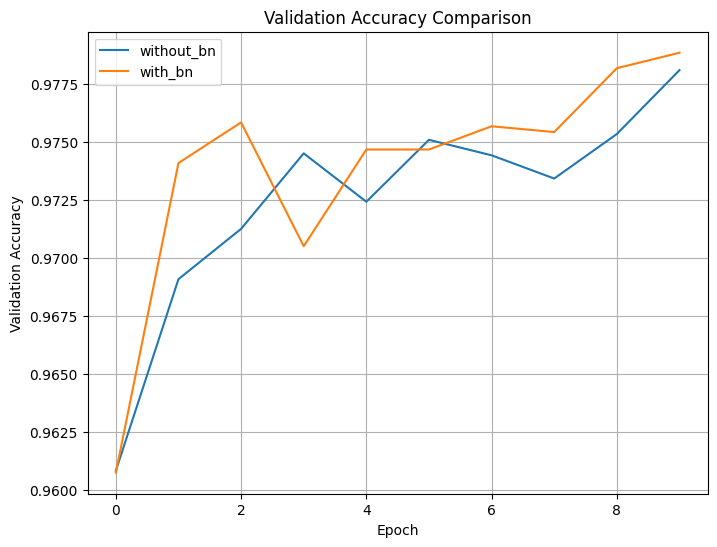

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history_no_bn.history['val_accuracy'], label='without_bn')
plt.plot(history_bn.history['val_accuracy'], label='with_bn')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.grid(True)
plt.show()

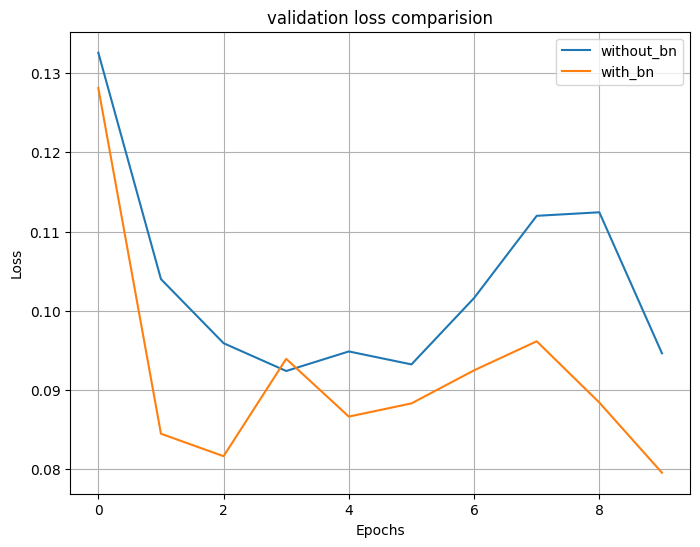

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history_no_bn.history['val_loss'], label='without_bn')
plt.plot(history_bn.history['val_loss'], label='with_bn')
plt.title('validation loss comparision')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()